In [1]:
from pathlib import Path
import os
import sys

import mne

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib qt

In [2]:
from modules.decode_trigger import decode_8bit_trigger, convert_dict_trigger
from modules.events import get_events_time, get_events_time_tms
from src.plotting import plot_boxplot_with_points

In [3]:
raw_data = mne.io.read_raw_bdf(r"data/raw/V1.bdf")

Extracting BDF parameters from data/raw/V1.bdf...
Setting channel info structure...
Creating raw.info structure...


In [4]:
events, event_id = mne.events_from_annotations(raw_data)
event_id = convert_dict_trigger(event_id, decode_8bit_trigger)

Used Annotations descriptions: [np.str_('8Bit 1'), np.str_('8Bit 10'), np.str_('8Bit 2'), np.str_('8Bit 3'), np.str_('8Bit 4'), np.str_('8Bit 5'), np.str_('Stimulus A')]


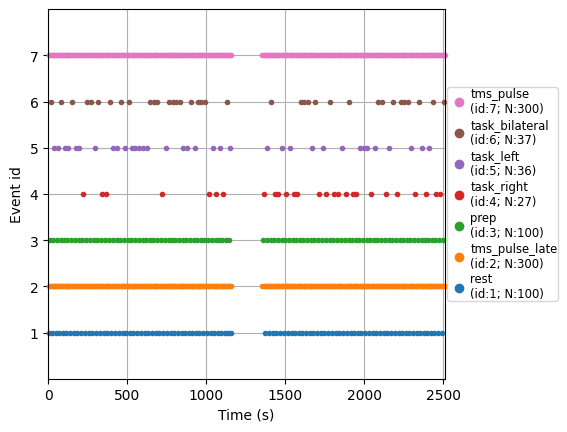

In [5]:
mne.viz.plot_events(
    events,
    sfreq=raw_data.info['sfreq'],  # converte para segundos
    event_id=event_id    # nomes dos eventos
)

In [6]:
rest, prep, task = get_events_time(events, event_id, raw_data.info["sfreq"])
plot_boxplot_with_points([rest, prep, task], ["Rest", "Prep", "Task"])

Evento 1 com tempo de 202.52980000000002 segundos, id: 450, proximo estado id: 453


In [7]:
rest_prep_tms, prep_task_tms, task_rest_tms = get_events_time_tms(events, event_id, raw_data.info["sfreq"])
plot_boxplot_with_points([rest_prep_tms, prep_task_tms, task_rest_tms], ["Rest-Prep TMS Pulse", "Prep-Task TMS Pulse", "Task-Rest TMS Pulse"])

Pulso TMS com intervalo de 199.6652 segundos, id: 449, estado anterior id: 447, proximo pulso id: 452, estado do proximo pulso id: 450
